In [2]:
import pandas as pd

df = pd.read_csv(r"D:/food-prediction/Datasets/food.csv")

print(df.shape)
df.head(1)

C:\Users\Suraj\AppData\Local\Temp\ipykernel_28872\2211134619.py:3: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:/food-prediction/Datasets/food.csv")


(645684, 26)


,businessname,dbaname,legalowner,namelast,namefirst,licenseno,issdttm,expdttm,licstatus,licensecat,...,violdttm,violstatus,statusdate,comments,address,city,state,zip,property_id,location
0,100 Percent Delicia Food,NaN,BRENNAN PATRICK E,Marte,Civelis,87059,2013-04-05 12:47:23,2020-12-31 23:59:00,Active,FS,...,2013-02-15 12:19:42,Fail,NaN,Provide glass storage rack.,635 Hyde Park AVE,Roslindale,MA,02131,77476.0,"(42.278590000, -71.119440000)"


In [14]:
df.shape

(645684, 26)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 645684 entries, 0 to 645683
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   businessname  645684 non-null  object 
 1   dbaname       6142 non-null    object 
 2   legalowner    442190 non-null  object 
 3   namelast      645684 non-null  object 
 4   namefirst     645570 non-null  object 
 5   licenseno     645684 non-null  int64  
 6   issdttm       645684 non-null  object 
 7   expdttm       645684 non-null  object 
 8   licstatus     645684 non-null  object 
 9   licensecat    645684 non-null  object 
 10  descript      645684 non-null  object 
 11  result        645684 non-null  object 
 12  resultdttm    645684 non-null  object 
 13  violation     609902 non-null  object 
 14  viollevel     609902 non-null  object 
 15  violdesc      608297 non-null  object 
 16  violdttm      645684 non-null  object 
 17  violstatus    609902 non-null  object 
 18  stat

In [16]:
df = df.sample(50000, random_state=42)
df.shape

(50000, 26)

In [17]:
df.isnull().sum()

businessname        0
dbaname         49531
legalowner      15844
namelast            0
namefirst          11
licenseno           0
issdttm             0
expdttm             0
licstatus           0
licensecat          0
descript            0
result              0
resultdttm          0
violation        2743
viollevel        2743
violdesc         2869
violdttm            0
violstatus       2743
statusdate      29183
comments            0
address             0
city                5
state               0
zip                 8
property_id     10545
location        13990
dtype: int64

In [22]:
print(df.columns)

Index(['licenseno', 'issdttm', 'expdttm', 'licstatus', 'licensecat',
       'descript', 'result', 'resultdttm', 'violation', 'viollevel',
       'violdttm', 'violstatus', 'city', 'state', 'zip'],
      dtype='object')


In [23]:
df.isnull().sum()

licenseno        0
issdttm          0
expdttm          0
licstatus        0
licensecat       0
descript         0
result           0
resultdttm       0
violation     2743
viollevel     2743
violdttm         0
violstatus    2743
city             5
state            0
zip              8
dtype: int64

In [24]:
df['violation'] = df['violation'].fillna('None')
df['viollevel'] = df['viollevel'].fillna('Unknown')
df['violstatus'] = df['violstatus'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')
df['zip'] = df['zip'].fillna(0)
df.isnull().sum()

licenseno     0
issdttm       0
expdttm       0
licstatus     0
licensecat    0
descript      0
result        0
resultdttm    0
violation     0
viollevel     0
violdttm      0
violstatus    0
city          0
state         0
zip           0
dtype: int64

In [29]:
df['issdttm'] = df['issdttm'].fillna(df['issdttm'].mode()[0])
df['expdttm'] = df['expdttm'].fillna(df['expdttm'].mode()[0])
df['resultdttm'] = df['resultdttm'].fillna(df['resultdttm'].mode()[0])
df['violdttm'] = df['violdttm'].fillna(df['violdttm'].mode()[0])
df.isnull().sum()

licenseno     0
issdttm       0
expdttm       0
licstatus     0
licensecat    0
descript      0
result        0
resultdttm    0
violation     0
viollevel     0
violdttm      0
violstatus    0
city          0
state         0
zip           0
dtype: int64

In [32]:
df['issdttm'] = pd.to_datetime(df['issdttm'], errors='coerce')
df['resultdttm'] = pd.to_datetime(df['resultdttm'], errors='coerce')
df[['issdttm','resultdttm']].dtypes

issdttm       datetime64[ns]
resultdttm    datetime64[ns]
dtype: object

In [34]:
df['issue_year'] = df['issdttm'].dt.year
df['issue_month'] = df['issdttm'].dt.month

df['result_year'] = df['resultdttm'].dt.year
df['result_month'] = df['resultdttm'].dt.month
df = df.drop(columns=['issdttm','expdttm','resultdttm','violdttm'])

In [35]:
df['result'].value_counts()

result
HE_Fail       21175
HE_Pass       15695
HE_Filed       6051
HE_FailExt     3659
HE_Hearing     1704
HE_NotReq       779
HE_TSOP         570
HE_OutBus       178
Pass             71
HE_Closure       48
HE_VolClos       31
Fail             15
HE_FAILNOR       12
HE_Misc          10
HE_Hold           1
DATAERR           1
Name: count, dtype: int64

In [39]:
fail_values = ['HE_Fail','HE_FailExt','Fail','HE_FAILNOR']

df['target'] = df['result'].apply(lambda x: 1 if x in fail_values else 0)
df['target'].value_counts()


target
0    25139
1    24861
Name: count, dtype: int64

In [40]:
df = df.drop(columns=['result'])

In [42]:
from sklearn.preprocessing import LabelEncoder
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [43]:
df.dtypes

licenseno         int64
licstatus         int64
licensecat        int64
descript          int64
violation         int64
viollevel         int64
violstatus        int64
city              int64
state             int64
zip               int64
issue_year      float64
issue_month     float64
result_year     float64
result_month    float64
target            int64
dtype: object

In [44]:
X = df.drop(columns=['target'])
y = df['target']

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [48]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8622


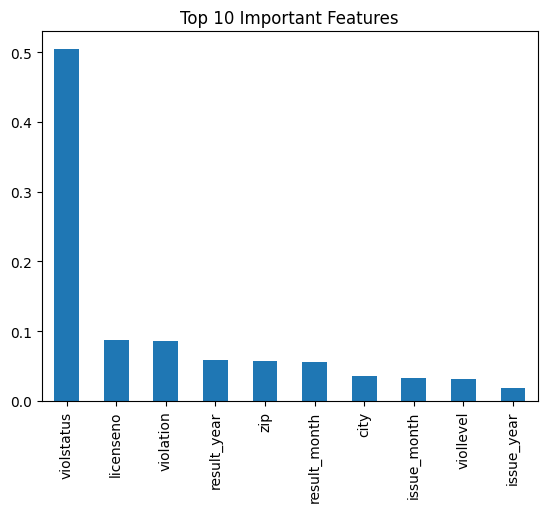

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(model.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 Important Features")
plt.show()

In [55]:
import os
import pickle

os.makedirs("models", exist_ok=True)

with open("models/model.pickle", "wb") as f:
    pickle.dump(model, f)

In [56]:
import pickle

with open("models/model.pickle", "wb") as f:
    pickle.dump(model, f)

In [57]:
import os
print(os.listdir("models"))

['model.pickle']


In [58]:
import pickle

with open("models/model.pickle", "rb") as f:
    model = pickle.load(f)

In [61]:
import os
import pickle

os.makedirs("models", exist_ok=True)

with open("models/model.pkl", "wb") as f:
    pickle.dump(model, f)
print(type(model))
print("Model saved successfully")

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
Model saved successfully
